# Báo cáo bài tập thực hành tuần 5
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

Import các thư viện cần thiết

In [1]:
pip install pyECLAT matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyECLAT import ECLAT

### 1. Cài đặt thuật toán Apriori

Phần này làm giống như trong file thực hành

In [3]:
# Load dữ liệu
df = pd.read_csv(r'D:\Data-Mining_MTH10358\Homeworks\TH\5\data.csv', header=None)
df

,0,1,2,3,4,5
0,Wine,Chips,Bread,Butter,Milk,Apple
1,Wine,NaN,Bread,Butter,Milk,NaN
2,NaN,NaN,Bread,Butter,Milk,NaN
3,NaN,Chips,NaN,NaN,NaN,Apple
4,Wine,Chips,Bread,Butter,Milk,Apple
5,Wine,Chips,NaN,NaN,Milk,NaN
6,Wine,Chips,Bread,Butter,NaN,Apple
7,Wine,Chips,NaN,NaN,Milk,NaN
8,Wine,NaN,Bread,NaN,NaN,Apple
9,Wine,NaN,Bread,Butter,Milk,NaN


Chuyển dữ liệu thành lớp ECLAT và khởi tạo DataFrame nhị phân

In [4]:
eclat_instance = ECLAT(data=df, verbose=True)
print(eclat_instance.df_bin)

100%|██████████| 6/6 [00:00<00:00, 1999.67it/s]

    Butter  Milk  Chips  Apple  Bread  Wine
0        1     1      1      1      1     1
1        1     1      0      0      1     1
2        1     1      0      0      1     0
3        0     0      1      1      0     0
4        1     1      1      1      1     1
5        0     1      1      0      0     1
6        1     0      1      1      1     1
7        0     1      1      0      0     1
8        0     0      0      1      1     1
9        1     1      0      0      1     1
10       1     0      1      1      1     0
11       1     1      0      1      0     1
12       1     1      1      0      1     1
13       0     1      0      1      1     1
14       1     1      0      1      1     1
15       1     1      1      1      1     1
16       1     1      1      1      1     0
17       1     1      1      1      0     0
18       1     1      1      1      1     1
19       1     1      0      1      1     1
20       0     1      1      1      1     1
21       0     0      1      0  

Khởi tạo các luật kết hợp

In [5]:
# count items in each row
items_per_transaction = eclat_instance.df_bin.astype(int).sum(axis=1)
# the item shoud appear at least at 5% of transactions
min_support = 0.6
# start from transactions containing at least 2 items
min_combination = 2
# up to maximum items per transaction
max_combination = max(items_per_transaction)
rule_indices, rule_supports = eclat_instance.fit(min_support=min_support,
                                                 min_combination=min_combination,
                                                 max_combination=max_combination,
                                                 separator=' & ',
                                                 verbose=True)

result = pd.DataFrame(rule_supports.items(),columns=['Item', 'Support'])
result1=result.sort_values(by=['Support'], ascending=False)
print(result1)

Combination 2 by 2


15it [00:00, 575.39it/s]


Combination 3 by 3


20it [00:00, 798.14it/s]


Combination 4 by 4


...

Combination 5 by 5


6it [00:00, 543.74it/s]


Combination 6 by 6


1it [00:00, 398.13it/s]

          Item   Support
0  Milk & Wine  0.636364


**Cài đặt thuật toán Vertical Apriori**

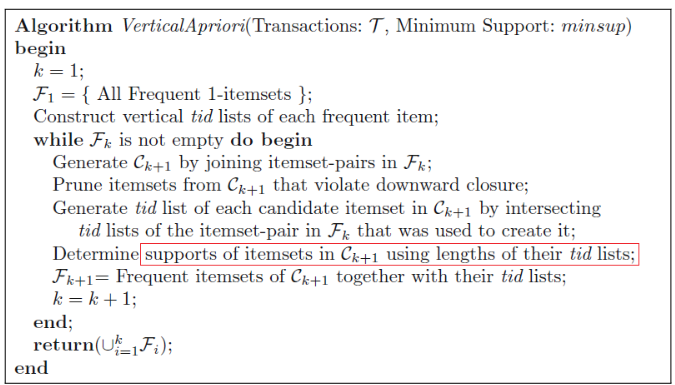

In [6]:
def has_infrequent_subset(D, Lk_1):
    for item in D:
        subset = D - frozenset([item])
        if subset not in Lk_1:
            return True
            
    return False

# def apriori_gen(Lk_1, k):
#     Ck = set()
#     Lk_1_list = list(Lk_1)
    
#     for i in range(len(Lk_1_list)):
#         for j in range(i + 1, len(Lk_1_list)):
#             l1 = list(Lk_1_list[i])
#             l2 = list(Lk_1_list[j])
#             l1.sort()
#             l2.sort()
            
#             if l1[:k-2] == l2[:k-2] and l1[k-2] != l2[k-2]:
#                 candidate = frozenset(l1) | frozenset(l2)
                
#                 if not has_infrequent_subset(candidate, Lk_1):
#                     Ck.add(candidate)
#     return Ck

# def apriori_homecooked(candidate, min_support):
#     num_candidate = len(candidate)
#     min_count = min_support * num_candidate 
    
#     trans_sets = [set(t) for t in candidate]
    
#     all_frequent_itemsets = {}
    
#     item_counts = {}
#     for t in trans_sets:
#         for item in t:
#             if str(item) != 'nan': 
#                 item_counts[frozenset([item])] = item_counts.get(frozenset([item]), 0) + 1
                
#     L1 = {itemset: count for itemset, count in item_counts.items() if count >= min_count}
#     all_frequent_itemsets.update(L1)
    
#     Lk_1 = L1
#     k = 2
    
#     while Lk_1:
#         Ck = apriori_gen(Lk_1.keys(), k)
        
#         Ck_counts = {c: 0 for c in Ck}
#         for t in trans_sets:
#             for candidate in Ck:
#                 if candidate.issubset(t):
#                     Ck_counts[candidate] += 1
                    
#         Lk = {c: count for c, count in Ck_counts.items() if count >= min_count}
        
#         if not Lk:
#             break
            
#         all_frequent_itemsets.update(Lk)
#         Lk_1 = Lk
#         k += 1
        
#     result = []
#     for itemset, count in all_frequent_itemsets.items():
#         support = count / num_candidate
#         result.append({
#             'support': support,
#             'itemsets': set(itemset)
#         })
        
#     return result


In [7]:
def vertical_apriori(transactions, min_support):
    num_transactions = len(transactions)
    min_count = min_support * num_transactions

    tid_lists = {}
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            if str(item) != 'nan': 
                item_set = frozenset([item])
                if item_set not in tid_lists:
                    tid_lists[item_set] = set()
                tid_lists[item_set].add(tid)
                
    Fk = {itemset: tids for itemset, tids in tid_lists.items() if len(tids) >= min_count}
    
    result = []
    
    for itemset, tids in Fk.items():
        result.append({
            'support': len(tids) / num_transactions,
            'itemsets': set(itemset)
        })
        
    k = 2 
    
    while Fk:
        Fk_keys = list(Fk.keys())
        Fk_next = {}
        
        for i in range(len(Fk_keys)):
            for j in range(i + 1, len(Fk_keys)):
                l1 = list(Fk_keys[i])
                l2 = list(Fk_keys[j])
                l1.sort()
                l2.sort()
                
                if l1[:k-2] == l2[:k-2] and l1[k-2] != l2[k-2]:
                    candidate = frozenset(l1) | frozenset(l2)
                    
                    if not has_infrequent_subset(candidate, Fk.keys()):
                        
                        candidate_tids = Fk[Fk_keys[i]].intersection(Fk[Fk_keys[j]])
                        
                        if len(candidate_tids) >= min_count:
                            Fk_next[candidate] = candidate_tids
                            
        Fk = Fk_next
        k += 1
        
        for itemset, tids in Fk.items():
            result.append({
                'support': len(tids) / num_transactions,
                'itemsets': set(itemset)
            })
            
    return result

Hàm `has_infrequent_subset` kiểm tra xem một tập con có phải là tập con không phổ biến hay không. Hoạt động theo cách bước sau:
1. Duyệt qua từng phần tử trong tập D.
2. Tạo một tập con bằng cách loại bỏ phần tử hiện tại khỏi D.
3. Kiểm tra xem tập con này có tồn tại trong Lk_1 hay không. Nếu không tồn tại, trả về True (có tập con không phổ biến).
4. Nếu tất cả các tập con đều phổ biến, trả về False.
```python
def has_infrequent_subset(D, Lk_1):
    for item in D:
        subset = D - frozenset([item])
        if subset not in Lk_1:
            return True
            
    return False
```

Hàm `apriori_vertical` thực hiện thuật toán Apriori theo cách tiếp cận dọc (vertical). Hoạt động theo cách bước sau:

1. Tạo một dictionary `tid_lists` để lưu trữ danh sách các transaction ID cho mỗi itemset đơn lẻ. Mục đích của bước này là chuyển đổi dữ liệu từ dạng ngang sang dạng dọc, giúp dễ dàng tính toán giao của các tập TID sau này.

    1.1. Duyệt qua từng transaction và từng item trong transaction (lọc item không phải là NaN). Thuật toán quét qua toàn bộ cơ sở dữ liệu đúng một lần duy nhất bằng vòng lặp `enumerate(transactions)`. Tại mỗi giao dịch, nó xét từng phần tử và dùng lệnh `if str(item) != 'nan':` để bỏ qua các giá trị rỗng hoặc không hợp lệ.

    1.2. Thêm TID vào danh sách TID của itemset tương ứng trong tid_lists. Các item hợp lệ được chuyển thành frozenset để có thể làm khóa cho dictionary. Nếu item chưa tồn tại trong tid_lists, một set trống sẽ được tạo. Sau đó, mã giao dịch tid hiện tại được thêm vào set của itemset tương ứng.

2. Lọc ra các itemset đơn lẻ có support lớn hơn hoặc bằng min và lưu vào `Fk`.Thuật toán tính toán số lần xuất hiện tối thiểu cần thiết bằng công thức `min_count = min_support * num_transactions`. Sau đó, nó duyệt qua `tid_lists` và chỉ giữ lại những 1-itemset có số lượng TID (tức chiều dài của set) đạt hoặc vượt qua ngưỡng `min_count` này. Tập hợp các itemset thỏa mãn được lưu vào biến `Fk`.
3. Thêm các itemset đơn lẻ vào kết quả và tạo `k = 2` để chuẩn bị cho bước tìm kiếm các tập lớn hơn.
4. Sử dụng vòng lặp để tạo các itemset lớn hơn từ `Fk`:Thuật toán sử dụng vòng lặp `while Fk:` để liên tục sinh ra các tập phổ biến có kích thước $k$ dựa trên danh sách các tập kích thước $k-1$ đã tìm được ở vòng trước.

    4.1. Duyệt qua tất cả cặp itemset trong `Fk`.

    4.2. Kiểm tra điều kiện join để tạo candidate itemset mới.

    4.3. Sử dụng hàm `has_infrequent_subset` để loại bỏ các candidate itemset có tập con không phổ biến.

    4.4. Tính toán danh sách TID cho candidate itemset bằng cách giao danh sách TID của hai itemset tạo thành candidate.

    4.5. Nếu số lượng TID của candidate itemset lớn hơn hoặc bằng `min_count`, thêm candidate vào `Fk_next`.

5. Cập nhật `Fk` bằng `Fk_next` và tiếp tục vòng lặp cho đến khi không còn itemset nào thoả mãn điều kiện. Kết thúc một vòng lặp, từ điển `Fk` được cập nhật thành `Fk_next` (tập các k-itemset vừa tìm được), biến `k` tăng thêm 1 và kết quả được bổ sung vào mảng `result` chung. Quá trình lặp lại từ bước 4 cho đến khi `Fk` rỗng (không thể tạo thêm bất kỳ candidate hợp lệ nào), lúc này thuật toán kết thúc và trả về toàn bộ mảng `result`.


```py
def vertical_apriori(transactions, min_support):
    num_transactions = len(transactions)
    min_count = min_support * num_transactions

    tid_lists = {}
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            if str(item) != 'nan': 
                item_set = frozenset([item])
                if item_set not in tid_lists:
                    tid_lists[item_set] = set()
                tid_lists[item_set].add(tid)
                
    Fk = {itemset: tids for itemset, tids in tid_lists.items() if len(tids) >= min_count}
    
    result = []
    
    for itemset, tids in Fk.items():
        result.append({
            'support': len(tids) / num_transactions,
            'itemsets': set(itemset)
        })
        
    k = 2 
    
    while Fk:
        Fk_keys = list(Fk.keys())
        Fk_next = {}
        
        for i in range(len(Fk_keys)):
            for j in range(i + 1, len(Fk_keys)):
                l1 = list(Fk_keys[i])
                l2 = list(Fk_keys[j])
                l1.sort()
                l2.sort()
                
                if l1[:k-2] == l2[:k-2] and l1[k-2] != l2[k-2]:
                    candidate = frozenset(l1) | frozenset(l2)
                    
                    if not has_infrequent_subset(candidate, Fk.keys()):
                        
                        candidate_tids = Fk[Fk_keys[i]].intersection(Fk[Fk_keys[j]])
                        
                        if len(candidate_tids) >= min_count:
                            Fk_next[candidate] = candidate_tids
                            
        Fk = Fk_next
        k += 1
        
        for itemset, tids in Fk.items():
            result.append({
                'support': len(tids) / num_transactions,
                'itemsets': set(itemset)
            })
            
    return result
```

In [8]:
dataset = [
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Bread", "Butter", "Milk"],                    
    ["Bread", "Butter", "Milk"],                            
    ["Chips", "Apple"],                                     
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Chips", "Milk"],                              
    ["Wine", "Chips", "Bread", "Butter", "Apple"],          
    ["Wine", "Chips", "Milk"],                              
    ["Wine", "Bread", "Apple"],                             
    ["Wine", "Bread", "Butter", "Milk"],                    
    ["Chips", "Bread", "Butter", "Apple"],                  
    ["Wine", "Butter", "Milk", "Apple"],                    
    ["Wine", "Chips", "Bread", "Butter", "Milk"],           
    ["Wine", "Bread", "Milk", "Apple"],                     
    ["Wine", "Bread", "Butter", "Milk", "Apple"],           
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Chips", "Bread", "Butter", "Milk", "Apple"],          
    ["Chips", "Butter", "Milk", "Apple"],                   
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Bread", "Butter", "Milk", "Apple"],           
    ["Wine", "Chips", "Bread", "Milk", "Apple"],            
    ["Chips"]                                               
]
frequent_items = vertical_apriori(dataset, min_support=0.6)
df_result = pd.DataFrame(frequent_items)
print(df_result)


    support      itemsets
0  0.727273        {Wine}
1  0.636364       {Chips}
2  0.727273       {Bread}
3  0.681818      {Butter}
4  0.772727        {Milk}
5  0.681818       {Apple}
6  0.636364  {Milk, Wine}


Như vậy kết quả giống y chang với hàm có sẵn trong thư viện pyECLAT